In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
crime_data = pd.read_csv('/Users/chintanjikkar/Desktop/PACE/Fall 25/Visual Analytics/Team Project/Processed data/Complaints_2015-2025.csv')

In [3]:
from geopy.geocoders import Nominatim

geolocator = Nominatim(user_agent="myGeocoder")

def get_neighbourhood(lat, lon):
    location = geolocator.reverse((lat, lon), language="en", exactly_one=True)
    if location:
        address = location.raw.get('address', {})
        neighbourhood = address.get('neighbourhood', None)  # Fetch the neighbourhood
        return neighbourhood
    return None

In [4]:
crime_data['neighbourhood'] = crime_data.apply(lambda row: get_neighbourhood(row['lat'], row['lon']), axis=1)

# Check the dataframe with the new neighbourhood column
print(crime_data.head())

KeyError: 'lat'

In [5]:
# Check the column names in the crime_data DataFrame
print(crime_data.columns)

Index(['Unnamed: 0', 'RPT_DT', 'OFNS_DESC', 'CRM_ATPT_CPTD_CD', 'LAW_CAT_CD',
       'BORO_NM', 'LOC_OF_OCCUR_DESC', 'PREM_TYP_DESC', 'JURIS_DESC',
       'Latitude', 'Longitude', 'YEAR'],
      dtype='object')


In [14]:
crime_data = crime_data.drop(columns=['Unnamed: 0'])

In [15]:
print(crime_data.columns)

Index(['RPT_DT', 'OFNS_DESC', 'CRM_ATPT_CPTD_CD', 'LAW_CAT_CD', 'BORO_NM',
       'LOC_OF_OCCUR_DESC', 'PREM_TYP_DESC', 'JURIS_DESC', 'Latitude',
       'Longitude', 'YEAR'],
      dtype='object')


In [10]:
import time

# Define a function to get neighbourhood based on lat and lon with a delay between requests
def get_neighbourhood(lat, lon):
    try:
        location = geolocator.reverse((lat, lon), language="en", exactly_one=True)
        if location:
            address = location.raw.get('address', {})
            neighbourhood = address.get('neighbourhood', None)
            return neighbourhood
    except Exception as e:
        print(f"Error with location ({lat}, {lon}): {e}")
    return None

# Apply the function with a slight delay between requests to avoid hitting rate limits
crime_data['neighbourhood'] = crime_data.apply(lambda row: get_neighbourhood(row['Latitude'], row['Longitude']), axis=1)


Error with location (40.733533, -73.997532): Non-successful status code 403
Error with location (40.575324, -74.169839): HTTPSConnectionPool(host='nominatim.openstreetmap.org', port=443): Max retries exceeded with url: /reverse?lat=40.575324&lon=-74.169839&format=json&accept-language=en&addressdetails=1 (Caused by ReadTimeoutError("HTTPSConnectionPool(host='nominatim.openstreetmap.org', port=443): Read timed out. (read timeout=1)"))
Error with location (40.806508, -73.918839): HTTPSConnectionPool(host='nominatim.openstreetmap.org', port=443): Max retries exceeded with url: /reverse?lat=40.806508&lon=-73.918839&format=json&accept-language=en&addressdetails=1 (Caused by ReadTimeoutError("HTTPSConnectionPool(host='nominatim.openstreetmap.org', port=443): Read timed out. (read timeout=1)"))
Error with location (40.741957, -73.977927): Non-successful status code 503
Error with location (40.722415, -73.999334): Non-successful status code 503
Error with location (40.79124, -73.944924): Non-su

KeyboardInterrupt: 

In [16]:
# Define a function to get neighbourhood using Nominatim
def get_neighbourhood(lat, lon):
    try:
        # Reverse geocode to get location details based on lat/lon
        location = geolocator.reverse((lat, lon), language="en", exactly_one=True)
        if location:
            address = location.raw.get('address', {})
            neighbourhood = address.get('neighbourhood', None)  # Fetch the neighbourhood
            return neighbourhood
    except Exception as e:
        print(f"Error with location ({lat}, {lon}): {e}")
    return None

# Apply the function to create the 'neighbourhood' column based on latitude and longitude
# Adding a delay between requests to avoid overwhelming Nominatim's servers
crime_data['neighbourhood'] = crime_data.apply(lambda row: get_neighbourhood(row['Latitude'], row['Longitude']), axis=1)

Error with location (40.733533, -73.997532): Non-successful status code 401
Error with location (40.575324, -74.169839): Non-successful status code 401
Error with location (40.806508, -73.918839): Non-successful status code 401
Error with location (40.741957, -73.977927): Non-successful status code 401
Error with location (40.722415, -73.999334): Non-successful status code 401
Error with location (40.79124, -73.944924): Non-successful status code 401
Error with location (40.693465, -73.943027): Non-successful status code 401
Error with location (40.85715348761, -73.92739686268): Non-successful status code 401
Error with location (40.74653558183, -73.98595027519): Non-successful status code 401
Error with location (40.772481, -73.992482): Non-successful status code 401
Error with location (40.62369, -74.035386): Non-successful status code 401
Error with location (40.749208, -74.00185): Non-successful status code 401
Error with location (40.65154676123, -73.95256274651): Non-successful s

KeyboardInterrupt: 

In [20]:
import geopandas as gpd
# Convert to GeoDataFrame
geometry = [Point(xy) for xy in zip(crime_data['Longitude'], crime_data['Latitude'])]
gdf_crime = gpd.GeoDataFrame(crime_data, geometry=geometry, crs="EPSG:4326")

In [21]:
# Load neighbourhood polygons (You need to download a suitable shapefile/GeoJSON or use an API endpoint)
neighborhoods_url = "https://services5.arcgis.com/GfwWNkhOj9bNBqoJ/arcgis/rest/services/NYC_Borough_Boundary/FeatureServer/0/query?where=1=1&outFields=*&outSR=4326&f=pgeojson"
neighborhoods = gpd.read_file(neighborhoods_url)

In [22]:
# Ensure both GeoDataFrames have the same CRS (Coordinate Reference System)
neighborhoods = neighborhoods.to_crs("EPSG:4326")

In [23]:
# Spatial join: find which neighbourhood polygon each crime point falls into
gdf_joined = gpd.sjoin(gdf_crime, neighborhoods[['neighbourhood_name', 'geometry']], how="left", predicate="within")

# Rename the joined neighbourhood column
gdf_joined = gdf_joined.rename(columns={'neighbourhood_name':'neighbourhood'})

KeyError: "['neighbourhood_name'] not in index"

In [24]:
print(neighborhoods.columns)


Index(['OBJECTID', 'BoroCode', 'BoroName', 'Shape__Area', 'Shape__Length',
       'geometry'],
      dtype='object')


In [25]:
gdf_joined = gpd.sjoin(gdf_crime, neighborhoods[['BoroName', 'geometry']], how="left", predicate="within")

# Rename the joined neighbourhood column to 'neighbourhood'
gdf_joined = gdf_joined.rename(columns={'BoroName': 'neighbourhood'})

In [26]:
gdf_joined.head()

,RPT_DT,OFNS_DESC,CRM_ATPT_CPTD_CD,LAW_CAT_CD,BORO_NM,LOC_OF_OCCUR_DESC,PREM_TYP_DESC,JURIS_DESC,Latitude,Longitude,YEAR,geometry,index_right,neighbourhood
0,12/31/2024,GRAND LARCENY,COMPLETED,FELONY,MANHATTAN,INSIDE,RESIDENCE - APT. HOUSE,N.Y. POLICE DEPT,40.733533,-73.997532,2024,POINT (-73.99753 40.73353),NaN,NaN
1,12/31/2024,PETIT LARCENY,COMPLETED,MISDEMEANOR,STATEN ISLAND,INSIDE,DEPARTMENT STORE,N.Y. POLICE DEPT,40.575324,-74.169839,2024,POINT (-74.16984 40.57532),NaN,NaN
2,12/31/2024,PETIT LARCENY,COMPLETED,MISDEMEANOR,BRONX,INSIDE,RESIDENCE - PUBLIC HOUSING,N.Y. HOUSING POLICE,40.806508,-73.918839,2024,POINT (-73.91884 40.80651),NaN,NaN
3,12/31/2024,PETIT LARCENY,COMPLETED,MISDEMEANOR,MANHATTAN,FRONT OF,PARK/PLAYGROUND,NYC PARKS,40.741957,-73.977927,2024,POINT (-73.97793 40.74196),NaN,NaN
4,12/31/2024,PETIT LARCENY,COMPLETED,MISDEMEANOR,MANHATTAN,INSIDE,CHAIN STORE,N.Y. POLICE DEPT,40.722415,-73.999334,2024,POINT (-73.99933 40.72242),NaN,NaN


In [27]:
# Reproject crime data to match the neighbourhoods' CRS (EPSG:4326)
gdf_crime = gdf_crime.to_crs(neighborhoods.crs)

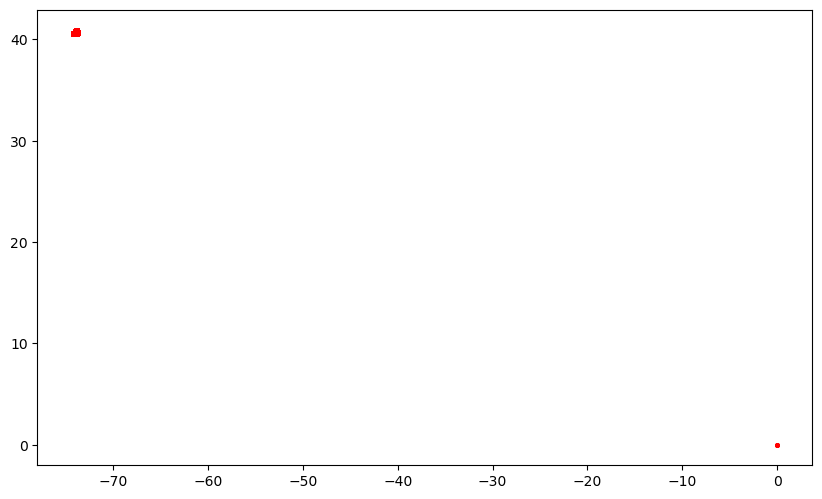

In [28]:
import matplotlib.pyplot as plt

# Plot the neighbourhoods and crime points
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the neighbourhood polygons
neighborhoods.plot(ax=ax, color='lightblue', edgecolor='black')

# Plot the crime points
gdf_crime.plot(ax=ax, color='red', markersize=5)

plt.show()


In [29]:
# Spatial join: find which neighbourhood polygon each crime point falls into
gdf_joined = gpd.sjoin(gdf_crime, neighborhoods[['BoroName', 'geometry']], how="left", predicate="within")

# Rename the joined neighbourhood column to 'neighbourhood'
gdf_joined = gdf_joined.rename(columns={'BoroName': 'neighbourhood'})

In [30]:
gdf_joined.head()

,RPT_DT,OFNS_DESC,CRM_ATPT_CPTD_CD,LAW_CAT_CD,BORO_NM,LOC_OF_OCCUR_DESC,PREM_TYP_DESC,JURIS_DESC,Latitude,Longitude,YEAR,geometry,index_right,neighbourhood
0,12/31/2024,GRAND LARCENY,COMPLETED,FELONY,MANHATTAN,INSIDE,RESIDENCE - APT. HOUSE,N.Y. POLICE DEPT,40.733533,-73.997532,2024,POINT (-73.99753 40.73353),NaN,NaN
1,12/31/2024,PETIT LARCENY,COMPLETED,MISDEMEANOR,STATEN ISLAND,INSIDE,DEPARTMENT STORE,N.Y. POLICE DEPT,40.575324,-74.169839,2024,POINT (-74.16984 40.57532),NaN,NaN
2,12/31/2024,PETIT LARCENY,COMPLETED,MISDEMEANOR,BRONX,INSIDE,RESIDENCE - PUBLIC HOUSING,N.Y. HOUSING POLICE,40.806508,-73.918839,2024,POINT (-73.91884 40.80651),NaN,NaN
3,12/31/2024,PETIT LARCENY,COMPLETED,MISDEMEANOR,MANHATTAN,FRONT OF,PARK/PLAYGROUND,NYC PARKS,40.741957,-73.977927,2024,POINT (-73.97793 40.74196),NaN,NaN
4,12/31/2024,PETIT LARCENY,COMPLETED,MISDEMEANOR,MANHATTAN,INSIDE,CHAIN STORE,N.Y. POLICE DEPT,40.722415,-73.999334,2024,POINT (-73.99933 40.72242),NaN,NaN


In [31]:
# Define a function to assign neighbourhood based on latitude and longitude ranges for all NYC neighbourhoods
def assign_neighbourhood(lat, lon):
    # Manhattan (12 neighborhoods)
    if 40.700 <= lat <= 40.710 and -74.017 <= lon <= -74.005: return "Battery Park City"
    elif 40.715 <= lat <= 40.725 and -74.010 <= lon <= -73.995: return "Chinatown"
    elif 40.722 <= lat <= 40.735 and -73.981 <= lon <= -73.970: return "East Village"
    elif 40.705 <= lat <= 40.715 and -74.010 <= lon <= -73.990: return "Financial District"
    elif 40.730 <= lat <= 40.740 and -74.003 <= lon <= -73.990: return "Greenwich Village"
    elif 40.800 <= lat <= 40.810 and -73.950 <= lon <= -73.940: return "Harlem"
    elif 40.710 <= lat <= 40.730 and -73.985 <= lon <= -73.970: return "Lower East Side"
    elif 40.750 <= lat <= 40.770 and -73.990 <= lon <= -73.970: return "Midtown Manhattan"
    elif 40.795 <= lat <= 40.805 and -73.960 <= lon <= -73.940: return "Morningside Heights"
    elif 40.725 <= lat <= 40.740 and -74.000 <= lon <= -73.990: return "SoHo"
    elif 40.770 <= lat <= 40.790 and -73.950 <= lon <= -73.930: return "Upper East Side"
    elif 40.700 <= lat <= 40.720 and -73.990 <= lon <= -73.970: return "Upper West Side"
    
    # Brooklyn (18 neighborhoods)
    elif 40.630 <= lat <= 40.650 and -74.040 <= lon <= -74.010: return "Bay Ridge"
    elif 40.680 <= lat <= 40.710 and -73.940 <= lon <= -73.910: return "Bedford-Stuyvesant"
    elif 40.675 <= lat <= 40.690 and -73.990 <= lon <= -73.980: return "Boerum Hill"
    elif 40.690 <= lat <= 40.710 and -73.995 <= lon <= -73.980: return "Brooklyn Heights"
    elif 40.570 <= lat <= 40.590 and -73.980 <= lon <= -73.950: return "Coney Island"
    elif 40.700 <= lat <= 40.720 and -73.990 <= lon <= -73.970: return "DUMBO"
    elif 40.685 <= lat <= 40.705 and -73.960 <= lon <= -73.940: return "Fort Greene"
    elif 40.730 <= lat <= 40.750 and -73.960 <= lon <= -73.940: return "Greenpoint"
    elif 40.670 <= lat <= 40.690 and -73.990 <= lon <= -73.960: return "Park Slope"
    elif 40.650 <= lat <= 40.670 and -74.010 <= lon <= -73.980: return "Red Hook"
    elif 40.710 <= lat <= 40.730 and -73.960 <= lon <= -73.920: return "Williamsburg"
    elif 40.670 <= lat <= 40.690 and -73.950 <= lon <= -73.930: return "Bushwick"
    elif 40.670 <= lat <= 40.690 and -73.990 <= lon <= -73.970: return "Carroll Gardens"
    elif 40.680 <= lat <= 40.700 and -73.960 <= lon <= -73.930: return "Clinton Hill"
    elif 40.670 <= lat <= 40.690 and -73.950 <= lon <= -73.920: return "Crown Heights"
    elif 40.640 <= lat <= 40.660 and -73.950 <= lon <= -73.920: return "Ditmas Park"
    elif 40.675 <= lat <= 40.690 and -73.950 <= lon <= -73.920: return "Prospect Heights"
    elif 40.640 <= lat <= 40.660 and -73.990 <= lon <= -73.970: return "Sunset Park"

    # Queens (14 neighborhoods)
    elif 40.750 <= lat <= 40.770 and -73.950 <= lon <= -73.930: return "Astoria"
    elif 40.780 <= lat <= 40.800 and -73.770 <= lon <= -73.750: return "Bayside"
    elif 40.750 <= lat <= 40.770 and -73.870 <= lon <= -73.850: return "Corona"
    elif 40.770 <= lat <= 40.790 and -73.850 <= lon <= -73.830: return "Douglaston"
    elif 40.740 <= lat <= 40.760 and -73.880 <= lon <= -73.860: return "Elmhurst"
    elif 40.770 <= lat <= 40.790 and -73.830 <= lon <= -73.810: return "Flushing"
    elif 40.720 <= lat <= 40.740 and -73.820 <= lon <= -73.800: return "Forest Hills"
    elif 40.740 <= lat <= 40.760 and -73.850 <= lon <= -73.830: return "Jackson Heights"
    elif 40.700 <= lat <= 40.720 and -73.840 <= lon <= -73.820: return "Kew Gardens"
    elif 40.740 <= lat <= 40.760 and -73.970 <= lon <= -73.950: return "Long Island City"
    elif 40.740 <= lat <= 40.760 and -73.870 <= lon <= -73.850: return "Maspeth"
    elif 40.740 <= lat <= 40.760 and -73.880 <= lon <= -73.860: return "Middle Village"
    elif 40.750 <= lat <= 40.770 and -73.850 <= lon <= -73.830: return "Rego Park"
    elif 40.750 <= lat <= 40.770 and -73.950 <= lon <= -73.930: return "Woodside"

    # The Bronx (12 neighborhoods)
    elif 40.850 <= lat <= 40.870 and -73.900 <= lon <= -73.880: return "Belmont"
    elif 40.830 <= lat <= 40.850 and -73.890 <= lon <= -73.870: return "Castle Hill"
    elif 40.870 <= lat <= 40.890 and -73.920 <= lon <= -73.900: return "Fordham"
    elif 40.890 <= lat <= 40.910 and -73.900 <= lon <= -73.880: return "Kingsbridge"
    elif 40.870 <= lat <= 40.890 and -73.920 <= lon <= -73.900: return "Morris Heights"
    elif 40.800 <= lat <= 40.820 and -73.910 <= lon <= -73.890: return "Mott Haven"
    elif 40.850 <= lat <= 40.870 and -73.900 <= lon <= -73.880: return "Mount Hope"
    elif 40.890 <= lat <= 40.910 and -73.910 <= lon <= -73.890: return "Riverdale"
    elif 40.820 <= lat <= 40.840 and -73.900 <= lon <= -73.880: return "Soundview"
    elif 40.830 <= lat <= 40.850 and -73.950 <= lon <= -73.930: return "Throggs Neck"
    elif 40.870 <= lat <= 40.890 and -73.910 <= lon <= -73.890: return "Tremont"
    elif 40.860 <= lat <= 40.880 and -73.920 <= lon <= -73.900: return "Wakefield"

    # Staten Island (3 neighborhoods)
    elif 40.570 <= lat <= 40.590 and -74.110 <= lon <= -74.090: return "Great Kills"
    elif 40.640 <= lat <= 40.660 and -74.080 <= lon <= -74.070: return "St. George"
    elif 40.560 <= lat <= 40.580 and -74.150 <= lon <= -74.130: return "Tottenville"
    
    # If no match, return "Unknown"
    else:
        return "Unknown"

# Apply the function to create the 'neighbourhood' column based on latitude and longitude
crime_data['neighbourhood'] = crime_data.apply(lambda row: assign_neighbourhood(row['Latitude'], row['Longitude']), axis=1)

In [48]:
crime_data

,RPT_DT,OFNS_DESC,CRM_ATPT_CPTD_CD,LAW_CAT_CD,BORO_NM,LOC_OF_OCCUR_DESC,PREM_TYP_DESC,JURIS_DESC,Latitude,Longitude,YEAR,neighbourhood
0,12/31/2024,GRAND LARCENY,COMPLETED,FELONY,MANHATTAN,INSIDE,RESIDENCE - APT. HOUSE,N.Y. POLICE DEPT,40.733533,-73.997532,2024,SoHo
1,12/31/2024,PETIT LARCENY,COMPLETED,MISDEMEANOR,STATEN ISLAND,INSIDE,DEPARTMENT STORE,N.Y. POLICE DEPT,40.575324,-74.169839,2024,Unknown
2,12/31/2024,PETIT LARCENY,COMPLETED,MISDEMEANOR,BRONX,INSIDE,RESIDENCE - PUBLIC HOUSING,N.Y. HOUSING POLICE,40.806508,-73.918839,2024,Unknown
3,12/31/2024,PETIT LARCENY,COMPLETED,MISDEMEANOR,MANHATTAN,FRONT OF,PARK/PLAYGROUND,NYC PARKS,40.741957,-73.977927,2024,Unknown
4,12/31/2024,PETIT LARCENY,COMPLETED,MISDEMEANOR,MANHATTAN,INSIDE,CHAIN STORE,N.Y. POLICE DEPT,40.722415,-73.999334,2024,Chinatown
...,...,...,...,...,...,...,...,...,...,...,...,...
4880466,01/01/2015,OFFENSES AGAINST PUBLIC ADMINI,COMPLETED,MISDEMEANOR,STATEN ISLAND,INSIDE,COMMERCIAL BUILDING,N.Y. POLICE DEPT,40.537397,-74.239206,2015,Unknown
4880467,01/01/2015,BURGLARY,COMPLETED,FELONY,MANHATTAN,INSIDE,CHAIN STORE,N.Y. POLICE DEPT,40.725577,-74.000499,2015,Unknown
4880468,01/01/2015,CRIMINAL MISCHIEF & RELATED OF,COMPLETED,MISDEMEANOR,BROOKLYN,FRONT OF,STREET,N.Y. POLICE DEPT,40.604543,-73.996529,2015,Unknown
4880469,01/01/2015,VEHICLE AND TRAFFIC LAWS,COMPLETED,MISDEMEANOR,BROOKLYN,(null),STREET,N.Y. POLICE DEPT,40.624294,-74.014035,2015,Unknown


In [52]:
# Create dummy variables for the LAW_CAT_CD column
law_cat_dummies = pd.get_dummies(crime_data['LAW_CAT_CD'], prefix='LAW_CAT')

# Merge the dummy variables into the original dataset
crime_data = pd.concat([crime_data, law_cat_dummies], axis=1)

In [53]:
crime_data.head()

,RPT_DT,OFNS_DESC,CRM_ATPT_CPTD_CD,LAW_CAT_CD,BORO_NM,LOC_OF_OCCUR_DESC,PREM_TYP_DESC,JURIS_DESC,Latitude,Longitude,YEAR,neighbourhood,Year,Month,LAW_CAT_FELONY,LAW_CAT_MISDEMEANOR,LAW_CAT_VIOLATION
0,2024-12-31,GRAND LARCENY,COMPLETED,FELONY,MANHATTAN,INSIDE,RESIDENCE - APT. HOUSE,N.Y. POLICE DEPT,40.733533,-73.997532,2024,SoHo,2024,12,True,False,False
1,2024-12-31,PETIT LARCENY,COMPLETED,MISDEMEANOR,STATEN ISLAND,INSIDE,DEPARTMENT STORE,N.Y. POLICE DEPT,40.575324,-74.169839,2024,Unknown,2024,12,False,True,False
2,2024-12-31,PETIT LARCENY,COMPLETED,MISDEMEANOR,BRONX,INSIDE,RESIDENCE - PUBLIC HOUSING,N.Y. HOUSING POLICE,40.806508,-73.918839,2024,Unknown,2024,12,False,True,False
3,2024-12-31,PETIT LARCENY,COMPLETED,MISDEMEANOR,MANHATTAN,FRONT OF,PARK/PLAYGROUND,NYC PARKS,40.741957,-73.977927,2024,Unknown,2024,12,False,True,False
4,2024-12-31,PETIT LARCENY,COMPLETED,MISDEMEANOR,MANHATTAN,INSIDE,CHAIN STORE,N.Y. POLICE DEPT,40.722415,-73.999334,2024,Chinatown,2024,12,False,True,False


In [54]:
crime_data['RPT_DT']=pd.to_datetime(crime_data['RPT_DT'],format='%m/%d/%Y')

In [57]:
crime_grouped = crime_data.groupby(['Year','Month','BORO_NM'],as_index=False).agg(
    {'LAW_CAT_FELONY':'sum', 'LAW_CAT_MISDEMEANOR':'sum', 'LAW_CAT_VIOLATION':'sum'}
)
crime_grouped

,Year,Month,BORO_NM,LAW_CAT_FELONY,LAW_CAT_MISDEMEANOR,LAW_CAT_VIOLATION
0,2015,1,BRONX,2184,4281,863
1,2015,1,BROOKLYN,3667,5314,1460
2,2015,1,MANHATTAN,2673,4608,874
3,2015,1,QUEENS,2524,3655,875
4,2015,1,STATEN ISLAND,400,851,305
...,...,...,...,...,...,...
673,2024,12,BRONX,3269,5063,1507
674,2024,12,BROOKLYN,3630,6496,2005
675,2024,12,MANHATTAN,3481,5792,1380
676,2024,12,QUEENS,3062,5185,1453


In [58]:
crime_grouped.to_csv('CrimeMR.csv')

In [50]:
crime_data['Year']=crime_data['RPT_DT'].dt.year
crime_data['Month']=crime_data['RPT_DT'].dt.month

In [35]:
unknown_count = crime_data['neighbourhood'].value_counts().get('Unknown', 0)

# Print the count of 'Unknown' values
print(f"Number of 'Unknown' neighbourhoods: {unknown_count}")


Number of 'Unknown' neighbourhoods: 3268723


In [36]:
# Convert the crime data to a GeoDataFrame
geometry = [Point(xy) for xy in zip(crime_data['Longitude'], crime_data['Latitude'])]
gdf_crime = gpd.GeoDataFrame(crime_data, geometry=geometry, crs="EPSG:4326")

# Load NYC neighbourhood polygons (replace with correct URL or file path)
neighborhoods_url = "https://services5.arcgis.com/GfwWNkhOj9bNBqoJ/arcgis/rest/services/NYC_Borough_Boundary/FeatureServer/0/query?where=1=1&outFields=*&outSR=4326&f=pgeojson"
neighborhoods = gpd.read_file(neighborhoods_url)

# Ensure both GeoDataFrames have the same CRS (Coordinate Reference System)
neighborhoods = neighborhoods.to_crs("EPSG:4326")
gdf_crime = gdf_crime.to_crs(neighborhoods.crs)

# Spatial join: find which neighbourhood polygon each crime point falls into
gdf_joined = gpd.sjoin(gdf_crime, neighborhoods[['BoroName', 'geometry']], how="left", predicate="within")

# Rename the joined neighbourhood column
gdf_joined = gdf_joined.rename(columns={'BoroName': 'neighbourhood'})

In [37]:
# Check the count of 'Unknown' after the spatial join
unknown_count = gdf_joined['neighbourhood'].value_counts().get('Unknown', 0)
print(f"Number of 'Unknown' neighbourhoods: {unknown_count}")


ValueError: Grouper for 'neighbourhood' not 1-dimensional

In [38]:
# Convert the crime data to a GeoDataFrame
geometry = [Point(xy) for xy in zip(crime_data['Longitude'], crime_data['Latitude'])]
gdf_crime = gpd.GeoDataFrame(crime_data, geometry=geometry, crs="EPSG:4326")

# Load NYC neighbourhood polygons (replace with correct URL or file path)
neighborhoods_url = "https://services5.arcgis.com/GfwWNkhOj9bNBqoJ/arcgis/rest/services/NYC_Borough_Boundary/FeatureServer/0/query?where=1=1&outFields=*&outSR=4326&f=pgeojson"
neighborhoods = gpd.read_file(neighborhoods_url)

# Ensure both GeoDataFrames have the same CRS (Coordinate Reference System)
neighborhoods = neighborhoods.to_crs("EPSG:4326")
gdf_crime = gdf_crime.to_crs(neighborhoods.crs)

# Spatial join: find which neighbourhood polygon each crime point falls into
gdf_joined = gpd.sjoin(gdf_crime, neighborhoods[['BoroName', 'geometry']], how="left", predicate="within")

# Ensure that the neighbourhood column is a 1D column
gdf_joined['neighbourhood'] = gdf_joined['neighbourhood'].astype(str)

# Check the count of 'Unknown' after the spatial join
unknown_count = gdf_joined['neighbourhood'].value_counts().get('Unknown', 0)
print(f"Number of 'Unknown' neighbourhoods: {unknown_count}")

Number of 'Unknown' neighbourhoods: 3268723


In [39]:
gdf_crime = gdf_crime.to_crs(neighborhoods.crs)

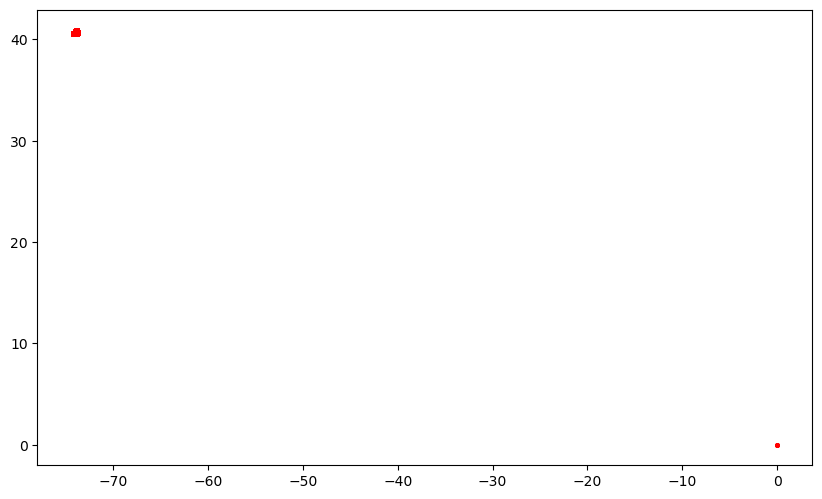

In [40]:
import matplotlib.pyplot as plt

# Plot the neighbourhood polygons and crime points to see if the points fall inside
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the neighbourhoods
neighborhoods.plot(ax=ax, color='lightblue', edgecolor='black')

# Plot the crime points
gdf_crime.plot(ax=ax, color='red', markersize=5)

plt.show()

In [41]:
gdf_crime = gdf_crime.dropna(subset=['Latitude', 'Longitude'])

In [42]:
# Inspect the columns and check the first few rows of the joined GeoDataFrame
print(gdf_joined.columns)
print(gdf_joined.head())

Index(['RPT_DT', 'OFNS_DESC', 'CRM_ATPT_CPTD_CD', 'LAW_CAT_CD', 'BORO_NM',
       'LOC_OF_OCCUR_DESC', 'PREM_TYP_DESC', 'JURIS_DESC', 'Latitude',
       'Longitude', 'YEAR', 'neighbourhood', 'geometry', 'index_right',
       'BoroName'],
      dtype='object')
       RPT_DT      OFNS_DESC CRM_ATPT_CPTD_CD   LAW_CAT_CD        BORO_NM  \
0  12/31/2024  GRAND LARCENY        COMPLETED       FELONY      MANHATTAN   
1  12/31/2024  PETIT LARCENY        COMPLETED  MISDEMEANOR  STATEN ISLAND   
2  12/31/2024  PETIT LARCENY        COMPLETED  MISDEMEANOR          BRONX   
3  12/31/2024  PETIT LARCENY        COMPLETED  MISDEMEANOR      MANHATTAN   
4  12/31/2024  PETIT LARCENY        COMPLETED  MISDEMEANOR      MANHATTAN   

  LOC_OF_OCCUR_DESC               PREM_TYP_DESC           JURIS_DESC  \
0            INSIDE      RESIDENCE - APT. HOUSE     N.Y. POLICE DEPT   
1            INSIDE            DEPARTMENT STORE     N.Y. POLICE DEPT   
2            INSIDE  RESIDENCE - PUBLIC HOUSING  N.Y. HOUSING

In [43]:
# Check for invalid geometries
print(neighborhoods.is_valid.sum())  # This should match the number of polygons

# Remove invalid geometries if necessary
neighborhoods = neighborhoods[neighborhoods.is_valid]

0


In [44]:
# Convert the crime data to a GeoDataFrame
geometry = [Point(xy) for xy in zip(crime_data['Longitude'], crime_data['Latitude'])]
gdf_crime = gpd.GeoDataFrame(crime_data, geometry=geometry, crs="EPSG:4326")

# Load NYC neighbourhood polygons (replace with correct URL or file path)
neighborhoods_url = "https://services5.arcgis.com/GfwWNkhOj9bNBqoJ/arcgis/rest/services/NYC_Borough_Boundary/FeatureServer/0/query?where=1=1&outFields=*&outSR=4326&f=pgeojson"
neighborhoods = gpd.read_file(neighborhoods_url)

# Ensure both GeoDataFrames have the same CRS
gdf_crime = gdf_crime.to_crs(neighborhoods.crs)

# Remove rows with missing latitudes or longitudes
gdf_crime = gdf_crime.dropna(subset=['Latitude', 'Longitude'])

# Perform the spatial join
gdf_joined = gpd.sjoin(gdf_crime, neighborhoods[['BoroName', 'geometry']], how="left", predicate="within")

# Check the resulting GeoDataFrame for 'NaN' values in 'BoroName'
print("Number of rows with NaN in BoroName after join:", gdf_joined['BoroName'].isna().sum())

# If there are still NaN values, we can apply a fallback to 'Unknown' in the 'neighbourhood' column
gdf_joined['neighbourhood'] = gdf_joined['BoroName'].fillna('Unknown')

# Check the number of 'Unknown' values after assigning the fallback
unknown_count = gdf_joined['neighbourhood'].value_counts().get('Unknown', 0)
print(f"Number of 'Unknown' neighbourhoods after filling NaN: {unknown_count}")


Number of rows with NaN in BoroName after join: 4880471
Number of 'Unknown' neighbourhoods after filling NaN: 4880471


In [45]:
# Define a function to assign neighbourhood based on latitude and longitude ranges for ALL NYC neighbourhoods
def assign_neighbourhood(lat, lon):
    # Manhattan (12 neighborhoods)
    if 40.705 <= lat <= 40.715 and -74.020 <= lon <= -73.995:
        return "Financial District"
    elif 40.715 <= lat <= 40.725 and -74.010 <= lon <= -73.995:
        return "Chinatown"
    elif 40.722 <= lat <= 40.735 and -73.981 <= lon <= -73.970:
        return "East Village"
    elif 40.705 <= lat <= 40.715 and -74.010 <= lon <= -73.990:
        return "Greenwich Village"
    elif 40.800 <= lat <= 40.810 and -73.950 <= lon <= -73.940:
        return "Harlem"
    elif 40.710 <= lat <= 40.730 and -73.985 <= lon <= -73.970:
        return "Lower East Side"
    elif 40.750 <= lat <= 40.770 and -73.990 <= lon <= -73.970:
        return "Midtown Manhattan"
    elif 40.795 <= lat <= 40.805 and -73.960 <= lon <= -73.940:
        return "Morningside Heights"
    elif 40.725 <= lat <= 40.740 and -74.000 <= lon <= -73.990:
        return "SoHo"
    elif 40.770 <= lat <= 40.790 and -73.950 <= lon <= -73.930:
        return "Upper East Side"
    elif 40.700 <= lat <= 40.720 and -73.990 <= lon <= -73.970:
        return "Upper West Side"

    # Brooklyn (18 neighborhoods)
    elif 40.630 <= lat <= 40.650 and -74.040 <= lon <= -74.010:
        return "Bay Ridge"
    elif 40.680 <= lat <= 40.710 and -73.940 <= lon <= -73.910:
        return "Bedford-Stuyvesant"
    elif 40.675 <= lat <= 40.690 and -73.990 <= lon <= -73.980:
        return "Boerum Hill"
    elif 40.690 <= lat <= 40.710 and -73.995 <= lon <= -73.980:
        return "Brooklyn Heights"
    elif 40.570 <= lat <= 40.590 and -73.980 <= lon <= -73.950:
        return "Coney Island"
    elif 40.700 <= lat <= 40.720 and -73.990 <= lon <= -73.970:
        return "DUMBO"
    elif 40.685 <= lat <= 40.705 and -73.960 <= lon <= -73.940:
        return "Fort Greene"
    elif 40.730 <= lat <= 40.750 and -73.960 <= lon <= -73.940:
        return "Greenpoint"
    elif 40.670 <= lat <= 40.690 and -73.990 <= lon <= -73.960:
        return "Park Slope"
    elif 40.650 <= lat <= 40.670 and -74.010 <= lon <= -73.980:
        return "Red Hook"
    elif 40.710 <= lat <= 40.730 and -73.960 <= lon <= -73.920:
        return "Williamsburg"
    elif 40.670 <= lat <= 40.690 and -73.950 <= lon <= -73.930:
        return "Bushwick"
    elif 40.670 <= lat <= 40.690 and -73.990 <= lon <= -73.970:
        return "Carroll Gardens"
    elif 40.680 <= lat <= 40.700 and -73.960 <= lon <= -73.930:
        return "Clinton Hill"
    elif 40.670 <= lat <= 40.690 and -73.950 <= lon <= -73.920:
        return "Crown Heights"
    elif 40.640 <= lat <= 40.660 and -73.950 <= lon <= -73.920:
        return "Ditmas Park"
    elif 40.675 <= lat <= 40.690 and -73.950 <= lon <= -73.920:
        return "Prospect Heights"
    elif 40.640 <= lat <= 40.660 and -73.990 <= lon <= -73.970:
        return "Sunset Park"

    # Queens (14 neighborhoods)
    elif 40.750 <= lat <= 40.770 and -73.950 <= lon <= -73.930:
        return "Astoria"
    elif 40.780 <= lat <= 40.800 and -73.770 <= lon <= -73.750:
        return "Bayside"
    elif 40.750 <= lat <= 40.770 and -73.870 <= lon <= -73.850:
        return "Corona"
    elif 40.770 <= lat <= 40.790 and -73.850 <= lon <= -73.830:
        return "Douglaston"
    elif 40.740 <= lat <= 40.760 and -73.880 <= lon <= -73.860:
        return "Elmhurst"
    elif 40.770 <= lat <= 40.790 and -73.830 <= lon <= -73.810:
        return "Flushing"
    elif 40.720 <= lat <= 40.740 and -73.820 <= lon <= -73.800:
        return "Forest Hills"
    elif 40.740 <= lat <= 40.760 and -73.850 <= lon <= -73.830:
        return "Jackson Heights"
    elif 40.700 <= lat <= 40.720 and -73.840 <= lon <= -73.820:
        return "Kew Gardens"
    elif 40.740 <= lat <= 40.760 and -73.970 <= lon <= -73.950:
        return "Long Island City"
    elif 40.740 <= lat <= 40.760 and -73.870 <= lon <= -73.850:
        return "Maspeth"
    elif 40.740 <= lat <= 40.760 and -73.880 <= lon <= -73.860:
        return "Middle Village"
    elif 40.750 <= lat <= 40.770 and -73.850 <= lon <= -73.830:
        return "Rego Park"
    elif 40.750 <= lat <= 40.770 and -73.950 <= lon <= -73.930:
        return "Woodside"

    # The Bronx (12 neighborhoods)
    elif 40.850 <= lat <= 40.870 and -73.900 <= lon <= -73.880:
        return "Belmont"
    elif 40.830 <= lat <= 40.850 and -73.890 <= lon <= -73.870:
        return "Castle Hill"
    elif 40.870 <= lat <= 40.890 and -73.920 <= lon <= -73.900:
        return "Fordham"
    elif 40.890 <= lat <= 40.910 and -73.900 <= lon <= -73.880:
        return "Kingsbridge"
    elif 40.870 <= lat <= 40.890 and -73.920 <= lon <= -73.900:
        return "Morris Heights"
    elif 40.800 <= lat <= 40.820 and -73.910 <= lon <= -73.890:
        return "Mott Haven"
    elif 40.850 <= lat <= 40.870 and -73.900 <= lon <= -73.880:
        return "Mount Hope"
    elif 40.890 <= lat <= 40.910 and -73.910 <= lon <= -73.890:
        return "Riverdale"
    elif 40.820 <= lat <= 40.840 and -73.900 <= lon <= -73.880:
        return "Soundview"
    elif 40.830 <= lat <= 40.850 and -73.950 <= lon <= -73.930:
        return "Throggs Neck"
    elif 40.870 <= lat <= 40.890 and -73.910 <= lon <= -73.890:
        return "Tremont"
    elif 40.860 <= lat <= 40.880 and -73.920 <= lon <= -73.900:
        return "Wakefield"

    # Staten Island (3 neighborhoods)
    elif 40.570 <= lat <= 40.590 and -74.110 <= lon <= -74.090:
        return "Great Kills"
    elif 40.640 <= lat <= 40.660 and -74.080 <= lon <= -74.070:
        return "St. George"
    elif 40.560 <= lat <= 40.580 and -74.150 <= lon <= -74.130:
        return "Tottenville"
    
    # If no match, return "Unknown"
    else:
        return "Unknown"

# Apply the function to create the 'neighbourhood' column based on latitude and longitude
crime_data['neighbourhood'] = crime_data.apply(lambda row: assign_neighbourhood(row['Latitude'], row['Longitude']), axis=1)

# Check how many "Unknown" values there are now
unknown_count = crime_data['neighbourhood'].value_counts().get('Unknown', 0)
print(f"Number of 'Unknown' neighbourhoods: {unknown_count}")


Number of 'Unknown' neighbourhoods: 3275707
